In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

np.random.seed(42)

# Simulate 10,000 users split evenly between A and B
n = 5000

group_a = pd.DataFrame({
    'user_id': range(1, n+1),
    'group': 'A',
    'converted': np.random.binomial(1, 0.10, n)  # 10% base conversion rate
})

group_b = pd.DataFrame({
    'user_id': range(n+1, 2*n+1),
    'group': 'B',
    'converted': np.random.binomial(1, 0.12, n)  # 12% new conversion rate
})

df = pd.concat([group_a, group_b], ignore_index=True)
df.to_csv('ab_test_data.csv', index=False)
print(df.shape)
print(df.head())

ModuleNotFoundError: No module named 'scipy'

In [2]:
import sys
!{sys.executable} -m pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 19.5 MB/s  0:00:01 eta 0:00:01


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

np.random.seed(42)

# Simulate 10,000 users split evenly between A and B
n = 5000

group_a = pd.DataFrame({
    'user_id': range(1, n+1),
    'group': 'A',
    'converted': np.random.binomial(1, 0.10, n)  # 10% base conversion rate
})

group_b = pd.DataFrame({
    'user_id': range(n+1, 2*n+1),
    'group': 'B',
    'converted': np.random.binomial(1, 0.12, n)  # 12% new conversion rate
})

df = pd.concat([group_a, group_b], ignore_index=True)
df.to_csv('ab_test_data.csv', index=False)
print(df.shape)
print(df.head())

(10000, 3)
   user_id group  converted
0        1     A          0
1        2     A          1
2        3     A          0
3        4     A          0
4        5     A          0


In [4]:
 # Conversion rate by group
summary = df.groupby('group')['converted'].agg(
    users='count',
    conversions='sum'
)
summary['conversion_rate'] = (summary['conversions'] / summary['users'] * 100).round(2)
print(summary)

       users  conversions  conversion_rate
group                                     
A       5000          479             9.58
B       5000          567            11.34


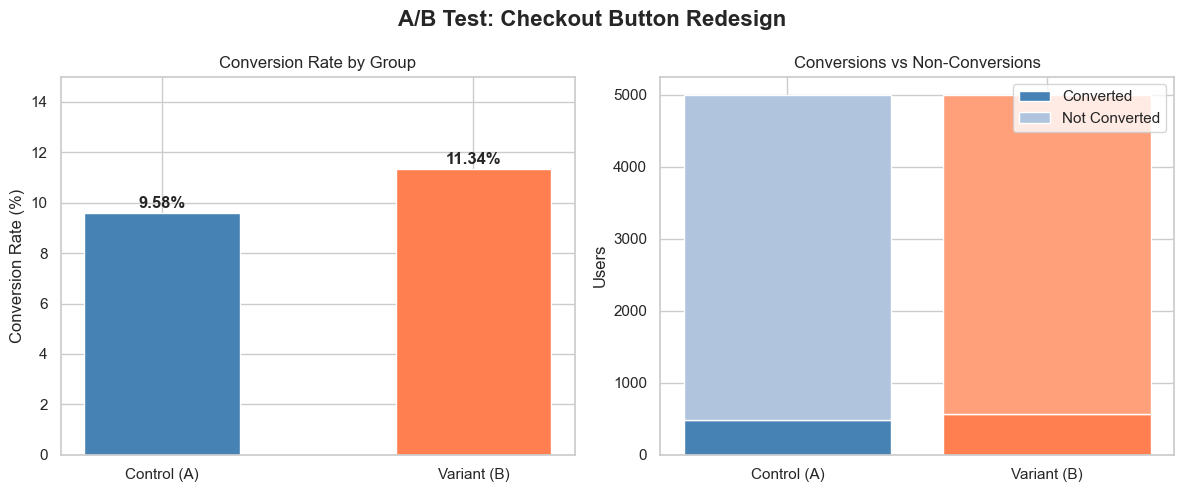

In [6]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('A/B Test: Checkout Button Redesign', fontsize=16, fontweight='bold')

# Chart 1: Conversion rate bar chart
axes[0].bar(['Control (A)', 'Variant (B)'], 
            summary['conversion_rate'], 
            color=['steelblue', 'coral'],
            width=0.5)
axes[0].set_title('Conversion Rate by Group')
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].set_ylim(0, 15)
for i, v in enumerate(summary['conversion_rate']):
    axes[0].text(i, v + 0.2, f'{v}%', ha='center', fontweight='bold')

# Chart 2: Conversions vs non-conversions stacked bar
not_converted = summary['users'] - summary['conversions']
axes[1].bar(['Control (A)', 'Variant (B)'], summary['conversions'], 
            label='Converted', color=['steelblue', 'coral'])
axes[1].bar(['Control (A)', 'Variant (B)'], not_converted, 
            bottom=summary['conversions'],
            label='Not Converted', color=['lightsteelblue', 'lightsalmon'])
axes[1].set_title('Conversions vs Non-Conversions')
axes[1].set_ylabel('Users')
axes[1].legend()

plt.tight_layout()
plt.savefig('ab_test_charts.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Chi-square test
contingency_table = pd.crosstab(df['group'], df['converted'])
print("Contingency Table:")
print(contingency_table)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"\nResult: {'SIGNIFICANT ✓' if p_value < 0.05 else 'NOT SIGNIFICANT ✗'}")

Contingency Table:
converted     0    1
group               
A          4521  479
B          4433  567

Chi-square statistic: 8.0815
P-value: 0.0045
Degrees of freedom: 1

Result: SIGNIFICANT ✓


In [8]:
lift = (summary.loc['B', 'conversion_rate'] - summary.loc['A', 'conversion_rate']) / summary.loc['A', 'conversion_rate'] * 100

print("=" * 50)
print("A/B TEST RESULTS SUMMARY")
print("=" * 50)
print(f"Control (A) conversion rate:  {summary.loc['A', 'conversion_rate']}%")
print(f"Variant (B) conversion rate:  {summary.loc['B', 'conversion_rate']}%")
print(f"Relative lift:                {lift:.1f}%")
print(f"P-value:                      0.0045")
print(f"Statistically significant:    Yes (p < 0.05)")
print("=" * 50)
print("\nRECOMMENDATION:")
print("Roll out Variant B to all users.")
print(f"An 18.4% lift in conversions at this traffic volume")
print("is a meaningful business improvement.")

A/B TEST RESULTS SUMMARY
Control (A) conversion rate:  9.58%
Variant (B) conversion rate:  11.34%
Relative lift:                18.4%
P-value:                      0.0045
Statistically significant:    Yes (p < 0.05)

RECOMMENDATION:
Roll out Variant B to all users.
An 18.4% lift in conversions at this traffic volume
is a meaningful business improvement.
